In [0]:
#1. Data Ingestion & Cleaning (Using SparkSQL and Spark DataFrames) 
spark

In [0]:
# ── PySpark Core ─────────────────────────────────────────────
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window
from pyspark.sql.functions import (
    col, lower, trim, when, sum, countDistinct,
    from_unixtime, datediff, to_date, lit, date_format
)

# ── PySpark ML — Pipeline & Feature Engineering ───────────────
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler as SparkStandardScaler

# ── PySpark ML — Clustering (K-Means) ────────────────────────
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# ── Scikit-learn — Models ─────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier

# ── Scikit-learn — Utilities ──────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix

# ── Python & Visualisation ────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time

#Task 1 - Data Ingestion and Cleaning

In [0]:
#Step 1. Loading the dataset
ednet_data = spark.read.option("header", "true").option("inferSchema", "true").csv("/Volumes/workspace/default/ednetdata/EdNet dataset.csv")

display(ednet_data.limit(10))

timestamp,action_type,item_id,source,user_answer,platform,user_id
1565096151269,enter,b3544,diagnosis,null,mobile,1
1565096187972,respond,q5012,diagnosis,b,mobile,1
1565096194904,submit,b3544,diagnosis,null,mobile,1
1565096195001,enter,b3238,diagnosis,null,mobile,1
1565096218682,respond,q4706,diagnosis,c,mobile,1
1565096223029,submit,b3238,diagnosis,null,mobile,1
1565096223119,enter,b2898,diagnosis,null,mobile,1
1565096290094,respond,q4366,diagnosis,b,mobile,1
1565096295925,submit,b2898,diagnosis,null,mobile,1
1565096296012,enter,b3361,diagnosis,null,mobile,1


In [0]:
#Step 2. Data Cleaning Stage 
ednet_data.printSchema()

root
 |-- timestamp: long (nullable = true)
 |-- action_type: string (nullable = true)
 |-- item_id: string (nullable = true)
 |-- source: string (nullable = true)
 |-- user_answer: string (nullable = true)
 |-- platform: string (nullable = true)
 |-- user_id: integer (nullable = true)



In [0]:
# --- Step 3: Checking Granularity (Interactions vs. Students) ---

# 1. Count raw interaction records
total_interactions = ednet_data.count()

# 2. Count unique students
unique_students = ednet_data.select("user_id").distinct().count()

print(f"Total Interaction Records: {total_interactions}")
print(f"Total Unique Students:    {unique_students}")

if total_interactions > unique_students:
    print(f"\n[ACTION] The dataset will collapse from {total_interactions} interaction-rows "
          f"to {unique_students} student-level rows during aggregation.")

Total Interaction Records: 89270654
Total Unique Students:    297915

[ACTION] The dataset will collapse from 89270654 interaction-rows to 297915 student-level rows during aggregation.


In [0]:
#Step 4: Converting the timestamp into readable time
ednet_data = ednet_data.withColumn("timestamp_readable",from_unixtime(col("timestamp")/1000))

display(ednet_data)

timestamp,action_type,item_id,source,user_answer,platform,user_id,timestamp_readable
1565096151269,enter,b3544,diagnosis,null,mobile,1,2019-08-06 12:55:51
1565096187972,respond,q5012,diagnosis,b,mobile,1,2019-08-06 12:56:27
1565096194904,submit,b3544,diagnosis,null,mobile,1,2019-08-06 12:56:34
1565096195001,enter,b3238,diagnosis,null,mobile,1,2019-08-06 12:56:35
1565096218682,respond,q4706,diagnosis,c,mobile,1,2019-08-06 12:56:58
1565096223029,submit,b3238,diagnosis,null,mobile,1,2019-08-06 12:57:03
1565096223119,enter,b2898,diagnosis,null,mobile,1,2019-08-06 12:57:03
1565096290094,respond,q4366,diagnosis,b,mobile,1,2019-08-06 12:58:10
1565096295925,submit,b2898,diagnosis,null,mobile,1,2019-08-06 12:58:15
1565096296012,enter,b3361,diagnosis,null,mobile,1,2019-08-06 12:58:16


In [0]:
#Step 5. Removing invalid or incomplete records
#(i) Removing rows where the following fields are missing
ednet_data = ednet_data.dropna(subset=["user_id", "timestamp", "action_type"])

#(ii) Removing duplicate records
ednet_data = ednet_data.dropDuplicates()

#(iii) Checking the row count before and after cleaning
print("Total rows:", ednet_data.count())

Total rows: 89194876


In [0]:
#Step 6. Standardizing categorical values - to convert them to lowercase and remove spaces
ednet_data = ednet_data.withColumn("action_type", trim(lower(col("action_type"))))

ednet_data = ednet_data.withColumn("platform", trim(lower(col("platform"))))

ednet_data = ednet_data.withColumn("source", trim(lower(col("source"))))

In [0]:
#Step 7. Using SparkSQL
ednet_data.createOrReplaceTempView("ednet")

print("SQL view 'ednet' registered successfully.")
print(f"Columns available: {ednet_data.columns}")

SQL view 'ednet' registered successfully.
Columns available: ['timestamp', 'action_type', 'item_id', 'source', 'user_answer', 'platform', 'user_id', 'timestamp_readable']


In [0]:
#Dataset overview
spark.sql("""
    SELECT
        COUNT(*) AS total_records,
        COUNT(DISTINCT user_id) AS unique_students,
        COUNT(DISTINCT item_id) AS unique_items,
        COUNT(DISTINCT source) AS unique_sources,
        MIN(timestamp_readable) AS earliest_interaction,
        MAX(timestamp_readable) AS latest_interaction
    FROM ednet """).show(truncate=False)


+-------------+---------------+------------+--------------+--------------------+-------------------+
|total_records|unique_students|unique_items|unique_sources|earliest_interaction|latest_interaction |
+-------------+---------------+------------+--------------+--------------------+-------------------+
|89194876     |297915         |29498       |8             |2018-08-27 08:44:52 |2019-11-27 17:50:52|
+-------------+---------------+------------+--------------+--------------------+-------------------+



In [0]:
#Action type distribution with percentage share
display(spark.sql("""
    SELECT
        action_type,
        COUNT(*) AS total_count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2)  AS percentage
    FROM ednet
    GROUP BY action_type
    ORDER BY total_count DESC """))

action_type,total_count,percentage
enter,32943087,36.93
respond,23308702,26.13
submit,16488061,18.49
quit,16455026,18.45


In [0]:
#Platform usage analysis
display(spark.sql("""
    SELECT
        platform,
        COUNT(*)                AS interaction_count,
        COUNT(DISTINCT user_id) AS unique_students,
        COUNT(DISTINCT item_id) AS unique_items_accessed
    FROM ednet
    GROUP BY platform
    ORDER BY interaction_count DESC """))

platform,interaction_count,unique_students,unique_items_accessed
mobile,63438940,206183,27928
web,25755936,102827,29081


In [0]:
#Hourly activity pattern
display(spark.sql("""
    SELECT
        HOUR(timestamp_readable)    AS hour_of_day,
        action_type,
        COUNT(*)                    AS interaction_count
    FROM ednet
    GROUP BY HOUR(timestamp_readable), action_type
    ORDER BY hour_of_day, action_type"""))

hour_of_day,action_type,interaction_count
0,enter,1182892
0,quit,590275
0,respond,784542
0,submit,589770
1,enter,1333336
1,quit,667125
1,respond,925651
1,submit,662722
2,enter,1445768
2,quit,727253


In [0]:
#Students with only a single interaction
spark.sql("""
    SELECT COUNT(*) AS students_with_single_interaction
    FROM (
        SELECT user_id, COUNT(*) AS cnt
        FROM ednet
        GROUP BY user_id
        HAVING cnt = 1
    ) """).show()

+--------------------------------+
|students_with_single_interaction|
+--------------------------------+
|                               0|
+--------------------------------+



In [0]:
#Step 8. Checking for outliers in interaction counts before aggregation
interaction_stats = ednet_data.groupBy("user_id") \
    .count() \
    .orderBy(F.desc("count"))

print("Top 10 most active users (raw interaction count):")
interaction_stats.show(10)

q1, q3 = interaction_stats.approxQuantile("count", [0.25, 0.75], 0.01)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f"IQR upper bound for interaction count: {upper_bound:.0f}")
print(f"Users above upper bound (potential outliers): {interaction_stats.filter(F.col('count') > upper_bound).count():,}")

Top 10 most active users (raw interaction count):
+-------+------+
|user_id| count|
+-------+------+
|   9582|169794|
|   7939| 95866|
|   9857| 92143|
|   4042| 64303|
|    995| 61824|
| 491454| 60966|
| 277461| 60328|
|   7531| 59148|
| 257736| 56780|
|   1466| 53202|
+-------+------+
only showing top 10 rows
IQR upper bound for interaction count: 160
Users above upper bound (potential outliers): 51,446


In [0]:
#Checking source diversity across the dataset
source_dist = ednet_data.groupBy("source").count().orderBy(F.desc("count"))
print(f"Total distinct sources: {ednet_data.select('source').distinct().count()}")
print("\nTop 10 most accessed sources:")
source_dist.show(10)

Total distinct sources: 8

Top 10 most accessed sources:
+--------------+--------+
|        source|   count|
+--------------+--------+
|        sprint|64616840|
|       my_note| 7033452|
|     diagnosis| 6621642|
|adaptive_offer| 5122323|
|   review_quiz| 3620216|
|        review|  803141|
|         tutor|  722038|
|       archive|  655224|
+--------------+--------+



In [0]:
# --- Step 9. Aggregating the interactions by student - Data Transformation Stage ---
# Capture the count BEFORE aggregation
raw_n = ednet_data.count()

# Perform the aggregation
student_ednet_data = ednet_data.groupBy("user_id").agg(
    F.count("*").alias("total_interactions"),
    F.countDistinct(F.to_date(F.col("timestamp_readable"))).alias("active_days"),
    F.min("timestamp_readable").alias("first_interaction"),
    F.max("timestamp_readable").alias("last_interaction")
)

# Capture the count AFTER aggregation
student_n = student_ednet_data.count()

# --- RECONCILIATION LOG ---
print(f"REPORTING CHECK:")
print(f"Raw Interaction Records (N_raw): {raw_n}")
print(f"Unique Student Profiles (N_students): {student_n}")
print(f"Reduction Ratio: {round(raw_n / student_n, 2)} interactions per student.")

display(student_ednet_data)

REPORTING CHECK:
Raw Interaction Records (N_raw): 89194876
Unique Student Profiles (N_students): 297915
Reduction Ratio: 299.4 interactions per student.


user_id,total_interactions,active_days,first_interaction,last_interaction
572066,1884,13,2019-04-22 07:40:21,2019-06-08 03:26:12
295104,2419,31,2018-10-27 01:06:38,2018-12-26 10:12:02
758639,4919,40,2019-10-06 23:16:56,2019-11-25 23:16:56
567062,2175,19,2019-04-15 07:27:54,2019-05-11 11:55:38
247584,492,4,2018-08-27 13:07:16,2018-08-30 14:06:57
692831,495,3,2019-07-25 11:15:37,2019-08-05 07:04:34
340740,1853,18,2019-02-18 04:36:12,2019-04-02 07:34:51
534796,33,1,2019-03-14 02:51:36,2019-03-14 02:57:56
553982,208,4,2019-03-30 11:10:44,2019-05-11 18:56:11
396141,10088,27,2019-02-02 15:14:04,2019-03-30 13:02:19


In [0]:
#Step 10. Calculating learning activity features
activity_ednet_data = ednet_data.groupBy("user_id").agg(
    sum(when(col("action_type") == "enter", 1).otherwise(0)).alias("learning_sessions"),
    sum(when(col("action_type") == "respond", 1).otherwise(0)).alias("question_responses"),
    sum(when(col("action_type") == "submit", 1).otherwise(0)).alias("submissions"))

In [0]:
#Step 11. Measuring content interaction
content_ednet_data = ednet_data.groupBy("user_id").agg(
    countDistinct("item_id").alias("unique_items"),
    countDistinct("source").alias("unique_sources"),
    countDistinct("platform").alias("platforms_used"))
display(content_ednet_data.limit(5))

user_id,unique_items,unique_sources,platforms_used
1021,233,7,1
2737,59,3,1
2936,786,6,1
4366,250,3,1
3683,244,6,2


In [0]:
# Step 12. Establishing the reference date for calculating recency 

max_timestamp_row = ednet_data.agg(F.max("timestamp_readable").alias("max_ts")).collect()[0]

reference_date = max_timestamp_row["max_ts"]

print(f"Dataset reference date (most recent interaction): {reference_date}")

Dataset reference date (most recent interaction): 2019-11-27 17:50:52


In [0]:
#Step 13. Computing each student's recency score
student_recency = ednet_data.groupBy("user_id").agg(F.max("timestamp_readable").alias("last_seen"))

print(f"Student recency table rows: {student_recency.count():,}")
print("Sample:")
student_recency.show(5, truncate=False)

Student recency table rows: 297,915
Sample:
+-------+-------------------+
|user_id|last_seen          |
+-------+-------------------+
|1021   |2019-11-16 05:13:04|
|94     |2019-06-26 10:04:58|
|1721   |2019-07-16 05:44:40|
|1007   |2019-10-12 08:00:24|
|1257   |2019-08-05 12:45:50|
+-------+-------------------+
only showing top 5 rows


In [0]:
#Step 14. Calculating days since last activity of each student
student_recency = student_recency.withColumn("last_seen_date", to_date(F.col("last_seen")))

student_recency = student_recency.withColumn("days_since_last_activity",
    datediff(to_date(lit(str(reference_date))), F.col("last_seen_date")))

print("Days since last activity — distribution:")
student_recency.select("days_since_last_activity").summary(
    "count", "min", "25%", "50%", "75%", "max").show()

Days since last activity — distribution:
+-------+------------------------+
|summary|days_since_last_activity|
+-------+------------------------+
|  count|                  297915|
|    min|                       0|
|    25%|                     118|
|    50%|                     246|
|    75%|                     328|
|    max|                     457|
+-------+------------------------+



In [0]:
#Step 15. Choosing the dropout threshold

threshold_row = student_recency.approxQuantile("days_since_last_activity", [0.70], 0.01)
dropout_threshold = int(threshold_row[0])

print(f"70th percentile of days_since_last_activity: {dropout_threshold} days")
print()
print("Interpretation: Students inactive for more than this many days")
print(f"({dropout_threshold} days) relative to the dataset end date are")
print("classified as dropout risk (label = 1).")

70th percentile of days_since_last_activity: 314 days

Interpretation: Students inactive for more than this many days
(314 days) relative to the dataset end date are
classified as dropout risk (label = 1).


In [0]:
#Step 16. Assigning the dropout label
student_recency = student_recency.withColumn(
    "dropout_risk",
    F.when(
        F.col("days_since_last_activity") > dropout_threshold, 1
    ).otherwise(0))

# Verify class balance
print("Class distribution")
class_dist = student_recency.groupBy("dropout_risk").count().withColumn("percentage", F.round(F.col("count") * 100.0 / student_recency.count(), 2))
class_dist.show()

Class distribution
+------------+------+----------+
|dropout_risk| count|percentage|
+------------+------+----------+
|           1| 89461|     30.03|
|           0|208454|     69.97|
+------------+------+----------+



In [0]:
#Step 17. Calculating the engagement intensity
final_features = student_ednet_data.join(activity_ednet_data, "user_id") \
                                   .join(content_ednet_data, "user_id")

final_features = final_features.withColumn(
    "avg_interactions_per_day",
    F.when(
        F.col("active_days") > 0,
        F.col("total_interactions") / F.col("active_days")
    ).otherwise(0.0)
)

In [0]:
# --- Step 18. Calculating Engagement and Lifespan ---

final_features = final_features.withColumn(
    "engagement_score_eda",
    col("total_interactions") + col("active_days") + col("unique_items")
)

final_features = final_features.withColumn(
    "student_lifespan",
    datediff(
        to_date(col("last_interaction")),
        to_date(col("first_interaction"))
    )
)

print("Feature Engineering complete.")
print("- 'engagement_score_eda' created for visualization (not for ML).")
print("- 'student_lifespan' created. WARNING: Shares 'last_interaction' anchor with label.")

Feature Engineering complete.
- 'engagement_score_eda' created for visualization (not for ML).
- 'student_lifespan' created. WARNING: Shares 'last_interaction' anchor with label.


In [0]:
# --- Step 19. Selecting columns for ML ---

final_dataset = final_features.join(
    student_recency.select("user_id", "dropout_risk"),
    on="user_id",
    how="left"
).dropna(subset=["dropout_risk"])

final_dataset = final_dataset.withColumn(
    "dropout_risk", F.col("dropout_risk").cast("int")
)

final_dataset = final_dataset.select(
    "user_id",
    "total_interactions",
    "active_days",
    "learning_sessions",
    "question_responses",
    "submissions",
    "unique_items",
    "unique_sources",
    "platforms_used",
    "avg_interactions_per_day",
    "student_lifespan", 
    "dropout_risk" 
)

display(final_dataset)
print(f"Total students for ML: {final_dataset.count():,}")

user_id,total_interactions,active_days,learning_sessions,question_responses,submissions,unique_items,unique_sources,platforms_used,avg_interactions_per_day,student_lifespan,dropout_risk
1021,446,12,172,102,81,233,7,1,37.166666666666664,134,0
2936,1493,3,601,291,310,786,6,1,497.6666666666667,2,0
2737,109,10,44,21,29,59,3,1,10.9,77,0
3683,475,22,191,93,87,244,6,2,21.59090909090909,126,0
4366,445,5,135,175,75,250,3,1,89.0,5,0
4885,930,4,362,206,183,521,4,1,232.5,15,0
5156,56,1,20,16,14,34,2,1,56.0,0,0
11451,57,2,18,21,4,27,2,1,28.5,2,0
15277,546,4,213,120,108,296,5,1,136.5,8,0
247584,492,4,191,110,100,267,3,1,123.0,3,1


Total students for ML: 297,915


In [0]:
#Step 20. Sanity Check
sanity = final_dataset.groupBy("dropout_risk").agg(
    F.count("*").alias("student_count"),
    F.round(F.avg("total_interactions"), 1).alias("avg_total_interactions"),
    F.round(F.avg("active_days"), 1).alias("avg_active_days")
)

print("Sanity check: label vs feature values")
sanity.show()
print()
print("Expected result:")
print("  dropout_risk=1 students should show different patterns in total_interactions")
print("  and active_days compared to dropout_risk=0 students, confirming the label")
print("  distinguishes between active and at-risk students.")

Sanity check: label vs feature values
+------------+-------------+----------------------+---------------+
|dropout_risk|student_count|avg_total_interactions|avg_active_days|
+------------+-------------+----------------------+---------------+
|           1|        89461|                 113.5|            1.6|
|           0|       208454|                 379.2|            3.7|
+------------+-------------+----------------------+---------------+


Expected result:
  dropout_risk=1 students should show different patterns in total_interactions
  and active_days compared to dropout_risk=0 students, confirming the label
  distinguishes between active and at-risk students.


In [0]:
#Step 21. To save the processed dataset

final_dataset.write \
.mode("overwrite") \
.parquet("/Volumes/workspace/default/ednetdata/student_at_risk_features_v1")

In [0]:
# Checking if data file is saved 
display(dbutils.fs.ls("/Volumes/workspace/default/ednetdata"))

path,name,size,modificationTime
dbfs:/Volumes/workspace/default/ednetdata/EdNet dataset.csv,EdNet dataset.csv,4387251148,1776208951000
dbfs:/Volumes/workspace/default/ednetdata/student_at_risk_features_v1/,student_at_risk_features_v1/,0,1776293901363


#Task 2 - Exploratory Data Analysis (EDA)

In [0]:
#Step 2. Summary statistics
final_dataset.describe().show()

+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------------+------------------+-------------------+
|summary|           user_id|total_interactions|      active_days| learning_sessions|question_responses|       submissions|      unique_items|    unique_sources|     platforms_used|avg_interactions_per_day|  student_lifespan|       dropout_risk|
+-------+------------------+------------------+-----------------+------------------+------------------+------------------+------------------+------------------+-------------------+------------------------+------------------+-------------------+
|  count|            297915|            297915|           297915|            297915|            297915|            297915|            297915|            297915|             297915|                  297915|            297915|             297915|
|   mean|498202.1330

In [0]:
#Step 3. Register final_dataset as a SQL view

final_dataset.createOrReplaceTempView("students")
print("SQL view 'students' registered successfully.")

SQL view 'students' registered successfully.


In [0]:
#Summary statistics per dropout category
display(spark.sql("""
    SELECT
        dropout_risk,
        COUNT(*)                                AS student_count,
        ROUND(AVG(total_interactions), 2)       AS avg_interactions,
        ROUND(AVG(active_days), 2)              AS avg_active_days,
        ROUND(AVG(learning_sessions), 2)        AS avg_sessions,
        ROUND(AVG(question_responses), 2)       AS avg_responses,
        ROUND(AVG(student_lifespan), 2)         AS avg_lifespan_days
    FROM students
    GROUP BY dropout_risk
    ORDER BY dropout_risk """))

dropout_risk,student_count,avg_interactions,avg_active_days,avg_sessions,avg_responses,avg_lifespan_days
0,208454,379.19,3.7,140.17,98.86,16.44
1,89461,113.47,1.59,41.64,30.19,2.19


In [0]:
#Dropout rate by platform diversity
display(spark.sql("""
    SELECT
        platforms_used,
        COUNT(*)                                AS student_count,
        SUM(dropout_risk)                       AS dropout_count,
        ROUND(AVG(dropout_risk) * 100, 2)       AS dropout_rate_pct,
        ROUND(AVG(total_interactions), 1)       AS avg_interactions
    FROM students
    GROUP BY platforms_used
    ORDER BY platforms_used """))

platforms_used,student_count,dropout_count,dropout_rate_pct,avg_interactions
1,286820,87990,30.68,211.4
2,11095,1471,13.26,2575.1


In [0]:
#Activity tier breakdown using CASE WHEN
display(spark.sql("""
    SELECT
        CASE
            WHEN total_interactions < 50   THEN 'Low (< 50)'
            WHEN total_interactions < 500  THEN 'Medium (50–499)'
            ELSE                                'High (500+)'
        END                                     AS activity_tier,
        COUNT(*)                                AS student_count,
        ROUND(AVG(dropout_risk) * 100, 2)       AS dropout_rate_pct,
        ROUND(MIN(total_interactions), 0)       AS min_interactions,
        ROUND(MAX(total_interactions), 0)       AS max_interactions
    FROM students
    GROUP BY 1
    ORDER BY min_interactions """))

activity_tier,student_count,dropout_rate_pct,min_interactions,max_interactions
Low (< 50),207346,34.1,2,49
Medium (50–499),61732,24.77,50,499
High (500+),28837,11.98,500,169794


In [0]:
#Top 15 most engaged students with RANK window function
display(spark.sql("""
    SELECT
    user_id,
    total_interactions,
    active_days,
    submissions,
    dropout_risk,
    RANK() OVER (ORDER BY total_interactions DESC) AS engagement_rank
FROM students
ORDER BY engagement_rank ASC
LIMIT 15 """))

user_id,total_interactions,active_days,submissions,dropout_risk,engagement_rank
9582,169794,340,31996,0,1
7939,95866,413,18947,0,2
9857,92143,318,18216,0,3
4042,64303,180,10510,0,4
995,61824,114,8137,0,5
491454,60966,46,12149,0,6
277461,60328,15,2844,1,7
7531,59148,93,10001,0,8
257736,56780,202,9326,0,9
1466,53202,283,10160,0,10


In [0]:
#Step 4. Dropout distribution
#final_dataset.groupBy("dropout_risk").count().show()

display(final_dataset.groupBy("dropout_risk").count())

dropout_risk,count
0,208454
1,89461


In [0]:
#Step 8. Correlation analysis
corr_interactions_dropout   = final_dataset.stat.corr("total_interactions", "dropout_risk")
corr_activedays_dropout     = final_dataset.stat.corr("active_days",         "dropout_risk")
corr_sessions_dropout       = final_dataset.stat.corr("learning_sessions",   "dropout_risk")
corr_lifespan_dropout       = final_dataset.stat.corr("student_lifespan",    "dropout_risk")

print("Key Correlations with dropout_risk")
print(f"  total_interactions  & dropout_risk : {corr_interactions_dropout:.4f}")
print(f"  active_days         & dropout_risk : {corr_activedays_dropout:.4f}")
print(f"  learning_sessions   & dropout_risk : {corr_sessions_dropout:.4f}")
print(f"  student_lifespan    & dropout_risk : {corr_lifespan_dropout:.4f}")
print()
print("Interpretation:")
print("A correlation close to 0 between behavioural features and dropout_risk")
print("confirms the label is genuinely independent of those features,")
print("validating our recency-based label construction approach.")
print("Note: student_lifespan shows some correlation with dropout_risk because")
print("students who disengaged early naturally have shorter lifespans. This is")
print("acknowledged and the feature is retained as it measures engagement duration,")
print("not recency directly.")

Key Correlations with dropout_risk
  total_interactions  & dropout_risk : -0.0853
  active_days         & dropout_risk : -0.1123
  learning_sessions   & dropout_risk : -0.0864
  student_lifespan    & dropout_risk : -0.1544

Interpretation:
A correlation close to 0 between behavioural features and dropout_risk
confirms the label is genuinely independent of those features,
validating our recency-based label construction approach.
Note: student_lifespan shows some correlation with dropout_risk because
students who disengaged early naturally have shorter lifespans. This is
acknowledged and the feature is retained as it measures engagement duration,
not recency directly.


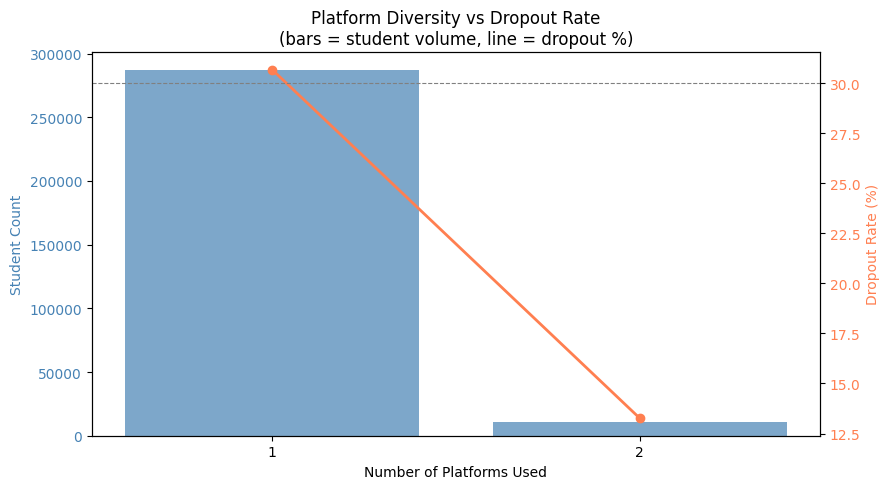


Key insight: If dropout rate decreases as platforms_used increases,
platform diversity is a meaningful protective factor against dropout.


In [0]:
#Step 9. Platform diversity effect
platform_pd = spark.sql("""
    SELECT
        platforms_used,
        COUNT(*)                          AS student_count,
        ROUND(AVG(dropout_risk)*100, 2)   AS dropout_rate_pct
    FROM students
    GROUP BY platforms_used
    ORDER BY platforms_used
""").toPandas()

fig, ax1 = plt.subplots(figsize=(9, 5))

color_bar = "steelblue"
ax1.bar(platform_pd["platforms_used"].astype(str),
        platform_pd["student_count"],
        color=color_bar, alpha=0.7, label="Student Count")
ax1.set_xlabel("Number of Platforms Used")
ax1.set_ylabel("Student Count", color=color_bar)
ax1.tick_params(axis="y", labelcolor=color_bar)

ax2 = ax1.twinx()
ax2.plot(platform_pd["platforms_used"].astype(str),
         platform_pd["dropout_rate_pct"],
         color="coral", marker="o", linewidth=2, label="Dropout Rate %")
ax2.set_ylabel("Dropout Rate (%)", color="coral")
ax2.tick_params(axis="y", labelcolor="coral")
ax2.axhline(y=30, color="gray", linestyle="--", linewidth=0.8, label="Overall 30% rate")

plt.title("Platform Diversity vs Dropout Rate\n(bars = student volume, line = dropout %)")
fig.tight_layout()
plt.show()

print("\nKey insight: If dropout rate decreases as platforms_used increases,")
print("platform diversity is a meaningful protective factor against dropout.")

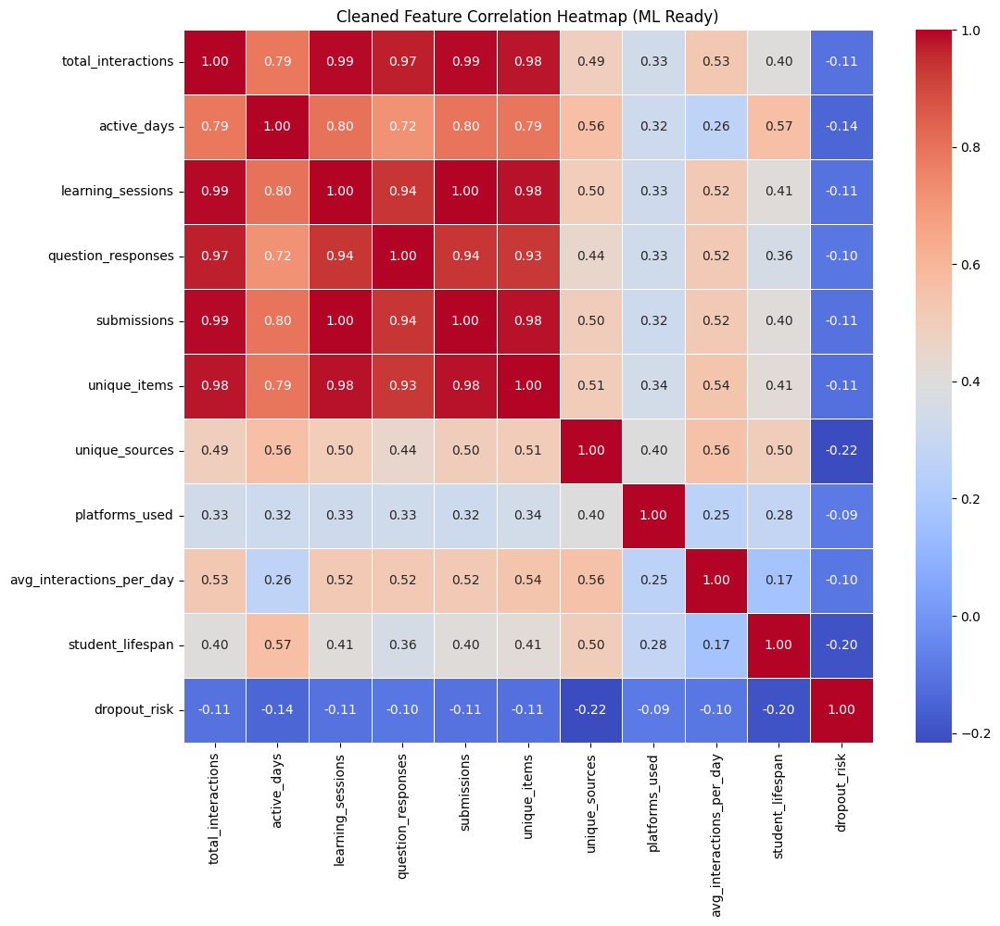

Note: student_lifespan shows correlation with dropout_risk by construction —
students who disengaged early have shorter lifespans. This is acknowledged
in the feature analysis section. All other feature correlations reflect
genuine behavioural patterns.


In [0]:
# --- Step 10. Correlation Heatmap ---

cols_to_exclude = ["user_id", "engagement_score"]
df_for_corr = final_dataset.drop(*[c for c in cols_to_exclude if c in final_dataset.columns])

pdf = df_for_corr.limit(10000).toPandas()

corr_matrix = pdf.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f",
    linewidths=0.5
)

plt.title("Cleaned Feature Correlation Heatmap (ML Ready)")
plt.show()

print("Note: student_lifespan shows correlation with dropout_risk by construction —")
print("students who disengaged early have shorter lifespans. This is acknowledged")
print("in the feature analysis section. All other feature correlations reflect")
print("genuine behavioural patterns.")

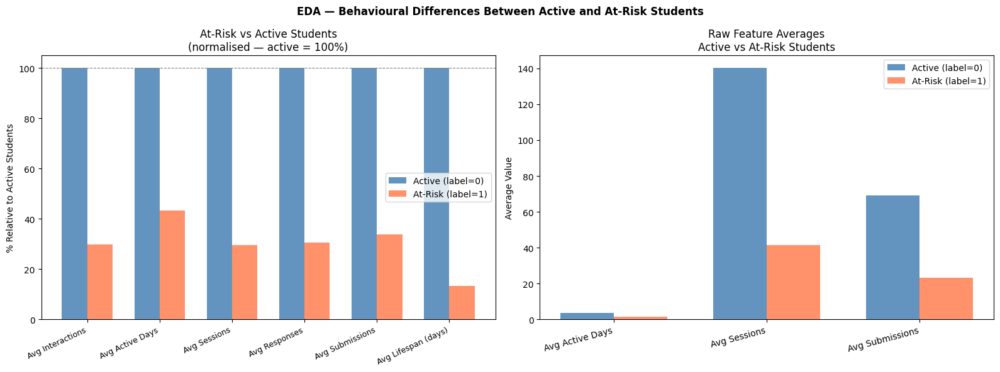


Key insight: Features with the largest gap between the two bars are the most likely to be important predictors in the ML models.


In [0]:
#Step 11 - Dropout vs Active — Feature Comparison Chart

comparison_pd = final_dataset.groupBy("dropout_risk").agg(
    F.round(F.avg("total_interactions"), 1).alias("Avg Interactions"),
    F.round(F.avg("active_days"), 1).alias("Avg Active Days"),
    F.round(F.avg("learning_sessions"), 1).alias("Avg Sessions"),
    F.round(F.avg("question_responses"), 1).alias("Avg Responses"),
    F.round(F.avg("submissions"), 1).alias("Avg Submissions"),
    F.round(F.avg("student_lifespan"), 1).alias("Avg Lifespan (days)")
).orderBy("dropout_risk").toPandas()

features = ["Avg Interactions", "Avg Active Days", "Avg Sessions",
            "Avg Responses", "Avg Submissions", "Avg Lifespan (days)"]

active_vals  = comparison_pd[comparison_pd["dropout_risk"] == 0][features].values[0]
atrisk_vals  = comparison_pd[comparison_pd["dropout_risk"] == 1][features].values[0]

active_pct  = np.array([100.0] * len(features))
atrisk_pct  = (atrisk_vals / active_vals) * 100

x     = np.arange(len(features))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(x - width/2, active_pct, width, label="Active (label=0)",
            color="steelblue", alpha=0.85)
axes[0].bar(x + width/2, atrisk_pct, width, label="At-Risk (label=1)",
            color="coral", alpha=0.85)
axes[0].axhline(y=100, color="gray", linestyle="--", linewidth=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(features, rotation=25, ha="right", fontsize=9)
axes[0].set_ylabel("% Relative to Active Students")
axes[0].set_title("At-Risk vs Active Students\n(normalised — active = 100%)")
axes[0].legend()

raw_features = ["Avg Active Days", "Avg Sessions", "Avg Submissions"]
active_raw = comparison_pd[comparison_pd["dropout_risk"] == 0][raw_features].values[0]
atrisk_raw = comparison_pd[comparison_pd["dropout_risk"] == 1][raw_features].values[0]
x2 = np.arange(len(raw_features))

axes[1].bar(x2 - width/2, active_raw, width, label="Active (label=0)",
            color="steelblue", alpha=0.85)
axes[1].bar(x2 + width/2, atrisk_raw, width, label="At-Risk (label=1)",
            color="coral", alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(raw_features, rotation=15, ha="right")
axes[1].set_ylabel("Average Value")
axes[1].set_title("Raw Feature Averages\nActive vs At-Risk Students")
axes[1].legend()

plt.suptitle("EDA — Behavioural Differences Between Active and At-Risk Students",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nKey insight: Features with the largest gap between the two bars are the most likely to be important predictors in the ML models.")

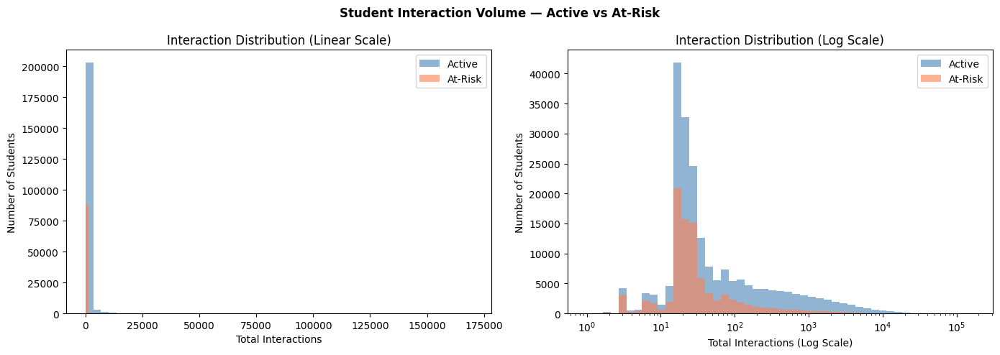

In [0]:
# --- Step 12. Student activity distribution (Log scale) ---


interactions_pd = final_dataset.select("total_interactions", "dropout_risk").toPandas()

active_data = interactions_pd[interactions_pd["dropout_risk"] == 0]["total_interactions"]
atrisk_data = interactions_pd[interactions_pd["dropout_risk"] == 1]["total_interactions"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(active_data, bins=50, alpha=0.6, color="steelblue", label="Active")
axes[0].hist(atrisk_data, bins=50, alpha=0.6, color="coral", label="At-Risk")
axes[0].set_xlabel("Total Interactions")
axes[0].set_ylabel("Number of Students")
axes[0].set_title("Interaction Distribution (Linear Scale)")
axes[0].legend()

axes[1].hist(active_data, bins=np.logspace(np.log10(1), np.log10(interactions_pd["total_interactions"].max()), 50), 
             alpha=0.6, color="steelblue", label="Active")
axes[1].hist(atrisk_data, bins=np.logspace(np.log10(1), np.log10(interactions_pd["total_interactions"].max()), 50), 
             alpha=0.6, color="coral", label="At-Risk")
axes[1].set_xscale("log")
axes[1].set_xlabel("Total Interactions (Log Scale)")
axes[1].set_ylabel("Number of Students")
axes[1].set_title("Interaction Distribution (Log Scale)")
axes[1].legend()

plt.suptitle("Student Interaction Volume — Active vs At-Risk", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

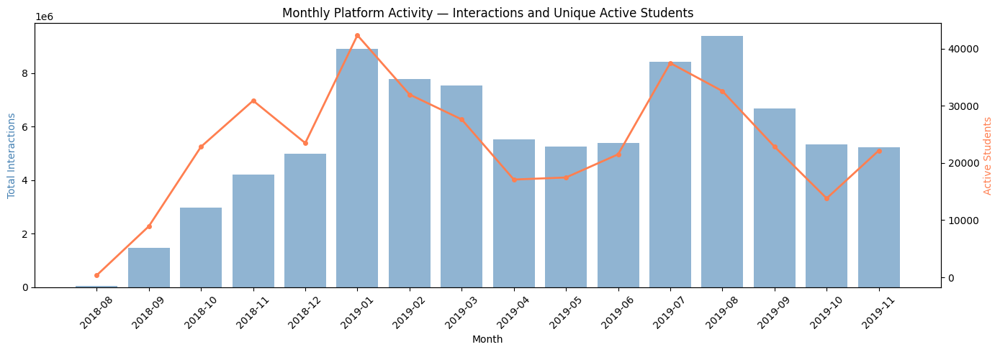

In [0]:
#Step 13 - Student Activity Over Time

# Add this to your aggregation
monthly_activity = ednet_data.withColumn(
    "month", date_format(F.col("timestamp_readable"), "yyyy-MM")
).groupBy("month").agg(
    F.count("*").alias("interaction_count"),
    F.countDistinct("user_id").alias("active_students")
).withColumn(
    "interactions_per_student", F.col("interaction_count") / F.col("active_students")
).orderBy("month").toPandas()

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(monthly_activity["month"],
        monthly_activity["interaction_count"],
        color="steelblue", alpha=0.6, label="Total Interactions")
ax1.set_xlabel("Month")
ax1.set_ylabel("Total Interactions", color="steelblue")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_activity["month"],
         monthly_activity["active_students"],
         color="coral", marker="o", linewidth=2, markersize=4,
         label="Active Students")
ax2.set_ylabel("Active Students", color="coral")

plt.title("Monthly Platform Activity — Interactions and Unique Active Students")
fig.tight_layout()
plt.show()

#Task 3 - Feature Analysis

In [0]:
# --- Step 1. Feature Importance with respect to Dropout Risk ---

dropout_feature_comparison = final_dataset.groupBy("dropout_risk").agg(
    F.avg("total_interactions").alias("avg_interactions"),
    F.avg("active_days").alias("avg_days"),
    F.avg("learning_sessions").alias("avg_sessions"),
    F.avg("question_responses").alias("avg_responses"),
    F.avg("submissions").alias("avg_submissions"),
    F.avg("unique_items").alias("avg_items"),
    F.avg("unique_sources").alias("avg_sources"),
    F.avg("platforms_used").alias("avg_platforms"),
    F.avg("avg_interactions_per_day").alias("avg_daily_rate"),
    F.avg("student_lifespan").alias("avg_lifespan") 
)


display(dropout_feature_comparison.orderBy("dropout_risk"))

dropout_risk,avg_interactions,avg_days,avg_sessions,avg_responses,avg_submissions,avg_items,avg_sources,avg_platforms,avg_daily_rate,avg_lifespan
0,379.19121724697055,3.701828700816487,140.1657440010746,98.8597292448214,69.07527320176153,182.90888637301276,1.9575349957304728,1.0461684592284148,50.3435157813182,16.43876346819922
1,113.46787985826226,1.5885134304333732,41.63799868098948,30.191882496283295,23.35144923486212,57.6458903879903,1.437531438280368,1.016442919260907,38.568681501497586,2.194062217055477


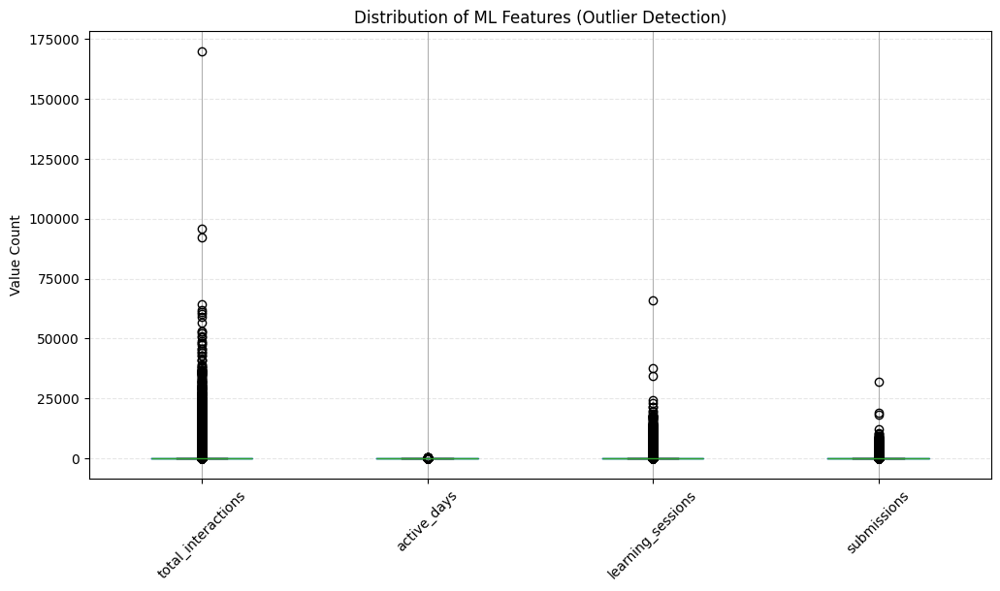

In [0]:
# --- Step 11. Boxplot of Key Features ---

ml_features = [
    "total_interactions",
    "active_days",
    "learning_sessions",
    "submissions"
]

pdf_dist = final_dataset.select(*ml_features).toPandas()

plt.figure(figsize=(12, 6))
pdf_dist.boxplot()

plt.title("Distribution of ML Features (Outlier Detection)")
plt.ylabel("Value Count")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

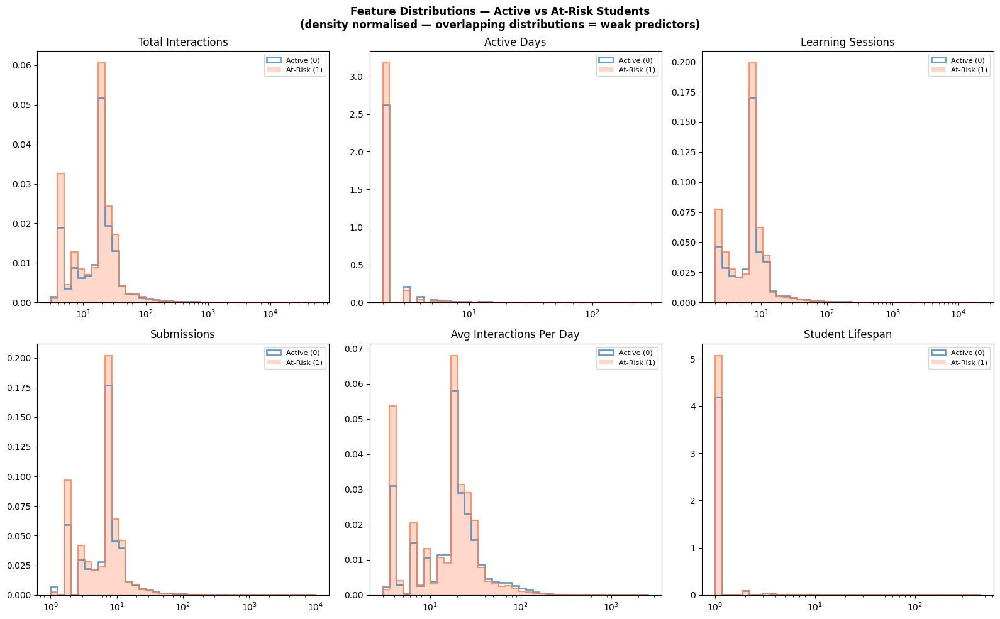

Features where blue and coral distributions are well separated are the most discriminative for predicting dropout risk. Features with heavy overlap contribute less as standalone predictors but may still contribute in combination within the ML models.


In [0]:
#Feature distribution comparison — Active vs At-Risk students

dist_pdf = final_dataset.select(
    "total_interactions",
    "active_days",
    "learning_sessions",
    "submissions",
    "avg_interactions_per_day",
    "student_lifespan",
    "dropout_risk"
).sample(False, 0.3, seed=42).toPandas()

features_to_plot = [
    "total_interactions",
    "active_days",
    "learning_sessions",
    "submissions",
    "avg_interactions_per_day",
    "student_lifespan"
]

active  = dist_pdf[dist_pdf["dropout_risk"] == 0]
atrisk  = dist_pdf[dist_pdf["dropout_risk"] == 1]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    min_val = dist_pdf[feature].min() + 1
    max_val = dist_pdf[feature].max() + 1
    bins = np.logspace(np.log10(min_val), np.log10(max_val), 40)

    axes[i].hist(active[feature] + 1, bins=bins, alpha=0.8,
                 color="steelblue", label="Active (0)", 
                 density=True, histtype='step', linewidth=2)
    
    axes[i].hist(atrisk[feature] + 1, bins=bins, alpha=0.3,
                 color="coral", label="At-Risk (1)", 
                 density=True, histtype='stepfilled')
    
    axes[i].hist(atrisk[feature] + 1, bins=bins, alpha=0.8,
                 color="coral", linewidth=1.5, 
                 density=True, histtype='step')

    axes[i].set_xscale("log")
    axes[i].set_title(feature.replace("_", " ").title())
    axes[i].legend(fontsize=8)

plt.suptitle(
    "Feature Distributions — Active vs At-Risk Students\n"
    "(density normalised — overlapping distributions = weak predictors)",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("Features where blue and coral distributions are well separated are the most discriminative for predicting dropout risk. Features with heavy overlap contribute less as standalone predictors but may still contribute in combination within the ML models.")

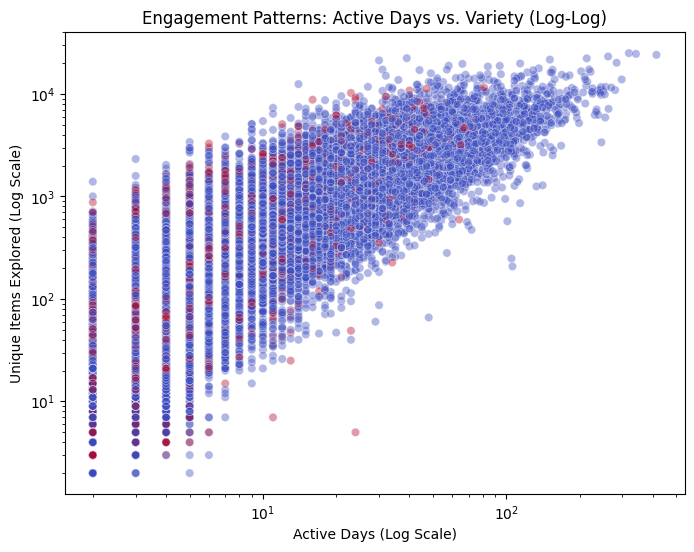

In [0]:
# --- Behavioral Independence ---

pdf_rel = final_dataset.select(
    "total_interactions", "active_days", "unique_items", "dropout_risk"
).toPandas()

plt.figure(figsize=(8,6))
plt.scatter(
    pdf_rel["active_days"] + 1,      
    pdf_rel["unique_items"] + 1, 
    c=pdf_rel["dropout_risk"], 
    cmap="coolwarm", 
    alpha=0.4,                       
    edgecolors='w', linewidth=0.5    
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Active Days (Log Scale)")
plt.ylabel("Unique Items Explored (Log Scale)")
plt.title("Engagement Patterns: Active Days vs. Variety (Log-Log)")
plt.show()

In [0]:
# --- Step 5 - student activity segmentation ---

segmented_dataset = final_dataset.withColumn(
    "activity_level",
    F.when(F.col("total_interactions") < 50, "Low")
    .when((F.col("total_interactions") >= 50) & (F.col("total_interactions") < 500), "Medium")
    .otherwise("High")
)

segment_order = ["Low", "Medium", "High"]

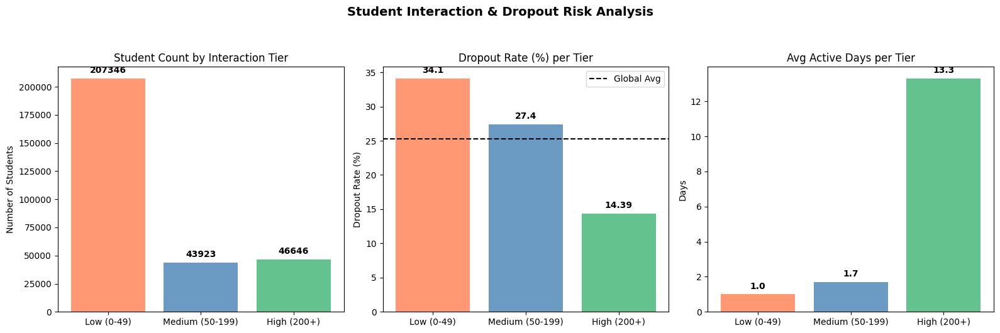

In [0]:

# 1. Define Tiers based on Total Interactions
segmented_dataset = final_dataset.withColumn(
    "interaction_segment",
    F.when(F.col("total_interactions") < 50, "Low (0-49)")
     .when(F.col("total_interactions") < 200, "Medium (50-199)")
     .otherwise("High (200+)")
)

# 2. Aggregating data for visualization
seg_pdf = segmented_dataset.groupBy("interaction_segment").agg(
    F.count("*").alias("student_count"),
    F.round(F.avg("dropout_risk") * 100, 2).alias("dropout_rate_pct"),
    F.round(F.avg("active_days"), 1).alias("avg_active_days")
).toPandas()

# 3. Logical Sorting
tier_order = ["Low (0-49)", "Medium (50-199)", "High (200+)"]
seg_pdf['interaction_segment'] = pd.Categorical(seg_pdf['interaction_segment'], categories=tier_order, ordered=True)
seg_pdf = seg_pdf.sort_values("interaction_segment")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ["#ff7f50", "#4682b4", "#3cb371"] 

axes[0].bar(seg_pdf["interaction_segment"], seg_pdf["student_count"], color=colors, alpha=0.8)
axes[0].set_title("Student Count by Interaction Tier")
axes[0].set_ylabel("Number of Students")

axes[1].bar(seg_pdf["interaction_segment"], seg_pdf["dropout_rate_pct"], color=colors, alpha=0.8)
axes[1].axhline(y=seg_pdf["dropout_rate_pct"].mean(), color="black", linestyle="--", label="Global Avg")
axes[1].set_title("Dropout Rate (%) per Tier")
axes[1].set_ylabel("Dropout Rate (%)")
axes[1].legend()

axes[2].bar(seg_pdf["interaction_segment"], seg_pdf["avg_active_days"], color=colors, alpha=0.8)
axes[2].set_title("Avg Active Days per Tier")
axes[2].set_ylabel("Days")

for ax in axes:
    for p in ax.patches:
        ax.annotate(f"{p.get_height()}", (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points', fontsize=10, fontweight='bold')

plt.suptitle("Student Interaction & Dropout Risk Analysis", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()

In [0]:
# --- Step 6 - Outlier Detection: Identifying Minimum Activity Thresholds ---

# 1. Bottom 10 by total interactions 
print("Bottom 10 Students by Interaction Volume:")
final_dataset.select("user_id", "total_interactions", "active_days", "dropout_risk") \
    .orderBy("total_interactions") \
    .show(10)

# 2. Bottom 10 by Active Days 
print("Bottom 10 Students by Consistency (Active Days):")
final_dataset.select("user_id", "active_days", "submissions", "dropout_risk") \
    .orderBy("active_days") \
    .show(10)

# 3. Bottom 10 by Submissions
print("Bottom 10 Students by Academic Output (Submissions):")
final_dataset.select("user_id", "submissions", "total_interactions", "dropout_risk") \
    .orderBy("submissions") \
    .show(10)

Bottom 10 Students by Interaction Volume:
+-------+------------------+-----------+------------+
|user_id|total_interactions|active_days|dropout_risk|
+-------+------------------+-----------+------------+
| 697619|                 2|          1|           0|
| 324753|                 2|          1|           1|
| 281268|                 2|          1|           1|
| 363338|                 2|          1|           1|
| 670899|                 2|          1|           0|
| 792832|                 2|          1|           0|
| 485292|                 2|          1|           0|
|   1645|                 2|          1|           0|
| 820828|                 2|          1|           0|
| 626771|                 2|          1|           0|
+-------+------------------+-----------+------------+
only showing top 10 rows
Bottom 10 Students by Consistency (Active Days):
+-------+-----------+-----------+------------+
|user_id|active_days|submissions|dropout_risk|
+-------+-----------+-----------+-

In [0]:
# Detect outliers using IQR for total_interactions
q1, q3 = final_dataset.approxQuantile("total_interactions", [0.25, 0.75], 0.01)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iqr)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

interaction_outliers = final_dataset.filter(
    (F.col("total_interactions") < lower_bound) | (F.col("total_interactions") > upper_bound)
)

print("Number of outliers in total_interactions:", interaction_outliers.count())
display(interaction_outliers)

Q1: 18.0
Q3: 76.0
IQR: 58.0
Lower Bound: -69.0
Upper Bound: 163.0
Number of outliers in total_interactions: 51063


user_id,total_interactions,active_days,learning_sessions,question_responses,submissions,unique_items,unique_sources,platforms_used,avg_interactions_per_day,student_lifespan,dropout_risk
1021,446,12,172,102,81,233,7,1,37.166666666666664,134,0
2936,1493,3,601,291,310,786,6,1,497.6666666666667,2,0
3683,475,22,191,93,87,244,6,2,21.59090909090909,126,0
4366,445,5,135,175,75,250,3,1,89.0,5,0
4885,930,4,362,206,183,521,4,1,232.5,15,0
15277,546,4,213,120,108,296,5,1,136.5,8,0
247584,492,4,191,110,100,267,3,1,123.0,3,1
16557,753,3,281,191,116,393,4,1,251.0,16,0
257987,595,7,237,121,80,269,4,1,85.0,34,0
249688,226,3,90,46,41,119,4,1,75.33333333333333,2,1


In [0]:
# --- GLOBAL CONFIGURATION: Feature Source of Truth ---

ML_FEATURES = [
    "total_interactions",
    "active_days",
    "learning_sessions",
    "question_responses",
    "submissions",
    "unique_items",
    "unique_sources",
    "platforms_used",
    "avg_interactions_per_day",
    "student_lifespan"
]

LABEL_COL = "dropout_risk"

In [0]:
# --- ML Phase: Train/Test Split & Feature Scaling Pipeline ---

# 1. SPLITTING THE DATASET
train_data, test_data = final_dataset.randomSplit([0.8, 0.2], seed=42)

print("--- Dataset Split Verification ---")
print(f"Total original rows: {final_dataset.count():,}")
print(f"Number of rows for training: {train_data.count():,}")
print(f"Number of rows for testing:  {test_data.count():,}\n")

# CONSTRUCTING THE PREPROCESSING PIPELINE
assembler = VectorAssembler(
    inputCols=ML_FEATURES,
    outputCol="features_vector",
    handleInvalid="error" 
)

scaler = SparkStandardScaler(
    inputCol="features_vector",
    outputCol="scaled_features",
    withStd=True,
    withMean=False
)

pipeline = Pipeline(stages=[assembler, scaler])

pipeline_model = pipeline.fit(train_data)

scaled_train_data = pipeline_model.transform(train_data)
scaled_test_data = pipeline_model.transform(test_data)

feature_names = ML_FEATURES
print("--- Post-Pipeline Verification ---")
print(f"scaled_train_data rows: {scaled_train_data.count():,}")
print(f"scaled_test_data rows:  {scaled_test_data.count():,}")
print(f"Features in vector:     {len(ML_FEATURES)}\n")

print("Sample of fully processed training data:")
display(scaled_train_data.select("user_id", "scaled_features", "dropout_risk").limit(5))


--- Dataset Split Verification ---
Total original rows: 297,915
Number of rows for training: 238,629
Number of rows for testing:  59,286

--- Post-Pipeline Verification ---
scaled_train_data rows: 238,629
scaled_test_data rows:  59,286
Features in vector:     10

Sample of fully processed training data:


user_id,scaled_features,dropout_risk
15,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""4.669002275818393"",""10.835421472862523"",""4.72938497388688"",""4.149633965321284"",""4.769061881298262"",""5.278573755265573"",""2.896606720982065"",""5.272838802449001"",""1.1311484737124762"",""4.4458143500747065""]}",0
20,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.3662099865406448"",""2.0971783495862946"",""0.3800398639730529"",""0.3028755825263236"",""0.3787555550475989"",""0.4273681158530114"",""3.6207584012275813"",""10.545677604898001"",""0.45839107689213093"",""3.31071281388542""]}",0
21,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.2765830682285941"",""3.2622774326897916"",""0.3531683584396047"",""0.06439087187567509"",""0.09774336904454164"",""0.09735412677732692"",""2.896606720982065"",""10.545677604898001"",""0.22255944801304636"",""8.844332802808193""]}",0
52,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.5545665570558139"",""0.6990594498620982"",""0.5758179757167468"",""0.4578906444492451"",""0.6027507757746735"",""0.6204262994622868"",""4.344910081473097"",""5.272838802449001"",""2.0824803034334667"",""0.14188769202366086""]}",0
56,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.014004205986257926"",""0.1165099083103497"",""0.013435752766724091"",""0.01430908263903891"",""0.028508482637991314"",""0.021450909289919492"",""0.7241516802455162"",""5.272838802449001"",""0.3155273187020404"",""0.0""]}",0


/home/spark-62467b49-8e84-4139-9c18-82/.ipykernel/2016/command-5986946999799559-693584276:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
/home/spark-62467b49-8e84-4139-9c18-82/.ipykernel/2016/command-5986946999799559-693584276:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


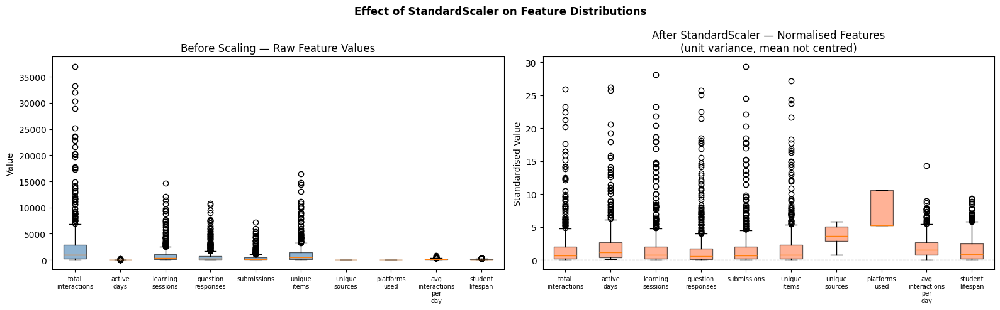

In [0]:
#Feature scaling: before vs after visualisation

comparison_pdf = scaled_train_data.select(
    ML_FEATURES + ["scaled_features"]
).limit(500).toPandas()

scaled_array = np.array(
    comparison_pdf["scaled_features"].apply(lambda v: v.toArray()).tolist()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].boxplot(
    [comparison_pdf[f].dropna().values for f in ML_FEATURES],
    labels=[f.replace("_", "\n") for f in ML_FEATURES],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6)
)
axes[0].set_title("Before Scaling — Raw Feature Values")
axes[0].set_ylabel("Value")
axes[0].tick_params(axis="x", labelsize=7)

axes[1].boxplot(
    [scaled_array[:, i] for i in range(len(ML_FEATURES))],
    labels=[f.replace("_", "\n") for f in ML_FEATURES],
    patch_artist=True,
    boxprops=dict(facecolor="coral", alpha=0.6)
)
axes[1].set_title("After StandardScaler — Normalised Features\n(unit variance, mean not centred)")
axes[1].set_ylabel("Standardised Value")
axes[1].axhline(y=0, color="black", linewidth=0.8, linestyle="--")
axes[1].tick_params(axis="x", labelsize=7)

plt.suptitle(
    "Effect of StandardScaler on Feature Distributions",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

feature,correlation_with_dropout
unique_sources,-0.17240395226217822
student_lifespan,-0.15436262557525113
active_days,-0.11229251959301394
unique_items,-0.09411866398589504
learning_sessions,-0.08642561032085361
total_interactions,-0.08533275638720812
submissions,-0.0852001047450504
avg_interactions_per_day,-0.08489807369894246
question_responses,-0.0761681990494565
platforms_used,-0.07195871082509546


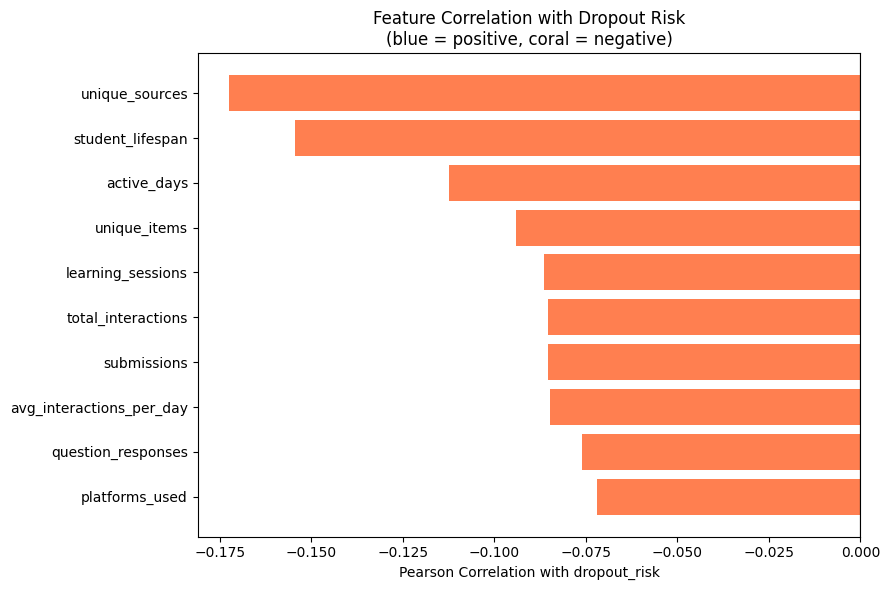


Interpretation:
  Features with larger absolute values carry more individual signal.
  Note: low individual correlation does not mean a feature is useless —
  ML models capture combined and non-linear patterns across all features.


In [0]:
#Step 8 - Feature relevance: correlation with dropout_risk
numeric_cols = [
    "total_interactions",
    "active_days",
    "learning_sessions",
    "question_responses",
    "submissions",
    "unique_items",
    "unique_sources",
    "platforms_used",
    "avg_interactions_per_day",
    "student_lifespan"
]

corr_results = []
for col_name in numeric_cols:
    corr_value = final_dataset.stat.corr(col_name, "dropout_risk")
    corr_results.append((col_name, corr_value))

corr_df = spark.createDataFrame(corr_results, ["feature", "correlation_with_dropout"])
display(corr_df.orderBy(F.abs(F.col("correlation_with_dropout")).desc()))

import matplotlib.pyplot as plt

corr_pd = corr_df.toPandas().sort_values(
    "correlation_with_dropout", key=abs, ascending=True
)
colors = ["coral" if v < 0 else "steelblue"
          for v in corr_pd["correlation_with_dropout"]]

plt.figure(figsize=(9, 6))
plt.barh(corr_pd["feature"], corr_pd["correlation_with_dropout"], color=colors)
plt.axvline(x=0, color="black", linewidth=0.8)
plt.xlabel("Pearson Correlation with dropout_risk")
plt.title("Feature Correlation with Dropout Risk\n(blue = positive, coral = negative)")
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Features with larger absolute values carry more individual signal.")
print("  Note: low individual correlation does not mean a feature is useless —")
print("  ML models capture combined and non-linear patterns across all features.")

In [0]:
#Percentile bucketing with NTILE window function
display(spark.sql("""
    SELECT
        engagement_quartile,
        COUNT(*)                            AS student_count,
        ROUND(AVG(dropout_risk) * 100, 2)   AS dropout_rate_pct,
        ROUND(AVG(total_interactions), 1)   AS avg_interactions,
        ROUND(AVG(active_days), 1)          AS avg_active_days,
        ROUND(AVG(student_lifespan), 1)     AS avg_lifespan_days
    FROM (
        SELECT *,
            NTILE(4) OVER (ORDER BY total_interactions) AS engagement_quartile
        FROM students
    )
    GROUP BY engagement_quartile
    ORDER BY engagement_quartile """))

engagement_quartile,student_count,dropout_rate_pct,avg_interactions,avg_active_days,avg_lifespan_days
1,74479,34.09,13.7,1.0,0.4
2,74479,33.06,21.6,1.0,0.8
3,74479,34.04,39.7,1.2,3.4
4,74478,18.93,1122.6,9.1,44.0


In [0]:
display(spark.sql("""
    SELECT
        interaction_bucket,
        student_count,
        dropout_in_bucket,
       
        SUM(student_count) OVER (ORDER BY interaction_bucket) 
                                        AS cumulative_students,
       
        SUM(dropout_in_bucket) OVER (ORDER BY interaction_bucket) 
                                        AS cumulative_dropouts,
       
        ROUND(
            SUM(dropout_in_bucket) OVER (ORDER BY interaction_bucket) * 100.0 / 
            SUM(student_count) OVER (ORDER BY interaction_bucket)
        , 2)                            AS running_dropout_rate_pct
    FROM (
        SELECT 
            FLOOR(total_interactions / 100) * 100     AS interaction_bucket,
            COUNT(*)                                  AS student_count,
            SUM(dropout_risk)                         AS dropout_in_bucket
        FROM students
        GROUP BY 1
    )
    WHERE interaction_bucket IS NOT NULL
    ORDER BY interaction_bucket 
"""))

interaction_bucket,student_count,dropout_in_bucket,cumulative_students,cumulative_dropouts,running_dropout_rate_pct
0,232784,78283,232784,78283,33.63
100,18485,4465,251269,82748,32.93
200,8319,1671,259588,84419,32.52
300,5559,962,265147,85381,32.20
400,3931,626,269078,86007,31.96
500,3132,469,272210,86476,31.77
600,2395,364,274605,86840,31.62
700,1965,281,276570,87121,31.50
800,1716,265,278286,87386,31.40
900,1433,174,279719,87560,31.30


In [0]:
#Compare each student to their platform-group average
display(spark.sql("""
    SELECT
        user_id,
        platforms_used,
        total_interactions,
        ROUND(AVG(total_interactions) OVER (PARTITION BY platforms_used), 1)
                                        AS platform_avg_interactions,
        ROUND(total_interactions -
              AVG(total_interactions) OVER (PARTITION BY platforms_used), 1)
                                        AS delta_from_platform_avg,
        dropout_risk
    FROM students
    ORDER BY delta_from_platform_avg DESC
    LIMIT 20 """))

user_id,platforms_used,total_interactions,platform_avg_interactions,delta_from_platform_avg,dropout_risk
9582,1,169794,211.4,169582.6,0
7939,2,95866,2575.1,93290.9,0
9857,2,92143,2575.1,89567.9,0
4042,2,64303,2575.1,61727.9,0
491454,1,60966,211.4,60754.6,0
277461,1,60328,211.4,60116.6,1
995,2,61824,2575.1,59248.9,0
7531,2,59148,2575.1,56572.9,0
257736,2,56780,2575.1,54204.9,0
1466,1,53202,211.4,52990.6,0


#Task 4 - Machine learning model implementation and Optimization

In [0]:
# --- ML PHASE: Convert to scikit-learn for model training ---

pdf = final_dataset.select(ML_FEATURES + ["dropout_risk"]).toPandas()

X = pdf[ML_FEATURES].values
y = pdf["dropout_risk"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

sk_scaler = StandardScaler()
X_train_sc = sk_scaler.fit_transform(X_train)
X_test_sc  = sk_scaler.transform(X_test)

print(f"Train size : {len(X_train)} students")
print(f"Test size  : {len(X_test)} students")
print(f"Features   : {len(ML_FEATURES)}")
print(f"Class balance (test) — Active: {(y_test==0).sum()}, At-Risk: {(y_test==1).sum()}")

Train size : 238332 students
Test size  : 59583 students
Features   : 10
Class balance (test) — Active: 41691, At-Risk: 17892


In [0]:
# --- Train all 6 models and capture metrics ---

def get_sklearn_metrics(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    f1  = round(f1_score(y_test, y_pred, average="weighted"), 4)
    acc = round(accuracy_score(y_test, y_pred), 4)
    auc = round(roc_auc_score(y_test, y_prob), 4)
    print(f"  {model_name:25s} → F1: {f1:.4f}  Acc: {acc:.4f}  AUC: {auc:.4f}")
    return {"F1": f1, "Accuracy": acc, "AUC-ROC": auc}

# --- Baseline models ---
print("── Training Baseline Models ──────────────────────────────")
baseline_defs = {
    "Random Forest":       RandomForestClassifier(n_estimators=20,  max_depth=5,  random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=100,                        random_state=42),
    "SVM":                 LinearSVC(max_iter=1000,                                random_state=42),
    "GBT":                 GradientBoostingClassifier(n_estimators=100,            random_state=42),
    "MLP (Neural Net)":    MLPClassifier(hidden_layer_sizes=(32,), max_iter=100,   random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=5,                     random_state=42),
}

baseline_trained = {}
baseline_f1_scores = {}
for name, clf in baseline_defs.items():
    clf.fit(X_train_sc, y_train)
    baseline_trained[name] = clf
    m = get_sklearn_metrics(clf, X_test_sc, y_test, name)
    baseline_f1_scores[name] = m["F1"]
custom_weight = {0: 1.0, 1: 1.5}
# --- Tuned models ---
print("\n── Training Tuned Models ─────────────────────────────────")

tuned_defs = {
   
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=12, 
                                                 class_weight=custom_weight, random_state=42),
    

    "Logistic Regression": LogisticRegression(C=1.0, class_weight=custom_weight, 
                                              max_iter=1000, random_state=42),
    
    "SVM":                LinearSVC(C=0.1, class_weight=custom_weight, 
                                    max_iter=2000, random_state=42),
    
    "GBT":                GradientBoostingClassifier(n_estimators=150, max_depth=5,
                                                     learning_rate=0.1, random_state=42),
    
    "MLP (Neural Net)":    MLPClassifier(hidden_layer_sizes=(32, 16), max_iter=500, 
                                         alpha=0.01, random_state=42),
    
    "Decision Tree":       DecisionTreeClassifier(max_depth=6, class_weight=custom_weight, 
                                                  random_state=42),
}

tuned_trained = {}
results = {}
tuned_f1_scores = {}
for name, clf in tuned_defs.items():
    clf.fit(X_train_sc, y_train)
    tuned_trained[name] = clf
    m = get_sklearn_metrics(clf, X_test_sc, y_test, name)
    results[name] = m
    tuned_f1_scores[name] = m["F1"]

best_rf_model  = tuned_trained["Random Forest"]
best_lr_model  = tuned_trained["Logistic Regression"]
best_svm_model = tuned_trained["SVM"]
best_gbt_model = tuned_trained["GBT"]
best_mlp_model = tuned_trained["MLP (Neural Net)"]
dt_model       = tuned_trained["Decision Tree"]

rf_baseline_f1  = baseline_f1_scores["Random Forest"]
lr_baseline_f1  = baseline_f1_scores["Logistic Regression"]
svm_baseline_f1 = baseline_f1_scores["SVM"]
gbt_baseline_f1 = baseline_f1_scores["GBT"]
mlp_baseline_f1 = baseline_f1_scores["MLP (Neural Net)"]
dt_baseline_f1  = baseline_f1_scores["Decision Tree"]

rf_tuned_f1  = tuned_f1_scores["Random Forest"]
lr_tuned_f1  = tuned_f1_scores["Logistic Regression"]
svm_tuned_f1 = tuned_f1_scores["SVM"]
gbt_tuned_f1 = tuned_f1_scores["GBT"]
mlp_tuned_f1 = tuned_f1_scores["MLP (Neural Net)"]

comparison_df = pd.DataFrame(results).T
print("\n── Final Comparison ──────────────────────────────────────")
print(comparison_df.to_string())

── Training Baseline Models ──────────────────────────────
  Random Forest             → F1: 0.5761  Acc: 0.6997  AUC: 0.6272
  Logistic Regression       → F1: 0.5761  Acc: 0.6997  AUC: 0.6037
  SVM                       → F1: 0.5761  Acc: 0.6997  AUC: 0.6033
  GBT                       → F1: 0.5761  Acc: 0.6997  AUC: 0.6359
  MLP (Neural Net)          → F1: 0.5761  Acc: 0.6996  AUC: 0.6198
  Decision Tree             → F1: 0.5761  Acc: 0.6997  AUC: 0.6262

── Training Tuned Models ─────────────────────────────────
  Random Forest             → F1: 0.6329  Acc: 0.6935  AUC: 0.6378
  Logistic Regression       → F1: 0.5762  Acc: 0.6995  AUC: 0.6039
  SVM                       → F1: 0.5761  Acc: 0.6995  AUC: 0.6035
  GBT                       → F1: 0.5766  Acc: 0.6996  AUC: 0.6392
  MLP (Neural Net)          → F1: 0.5761  Acc: 0.6997  AUC: 0.6209
  Decision Tree             → F1: 0.6283  Acc: 0.6915  AUC: 0.6215

── Final Comparison ──────────────────────────────────────
                 

In [0]:
# --- Model Interpretability ---

coef_lr = best_lr_model.coef_[0]
odds_df = pd.DataFrame({
    "feature":    ML_FEATURES,
    "coefficient": coef_lr,
    "odds_ratio":  np.exp(coef_lr)
}).sort_values("odds_ratio", ascending=False)
print("── LR Odds Ratios ────────────────────────────────────────")
print(odds_df.to_string(index=False))

coef_svm = best_svm_model.coef_[0]
svm_df = pd.DataFrame({
    "feature":     ML_FEATURES,
    "coefficient": coef_svm
}).sort_values("coefficient", key=abs, ascending=False)
print("\n── SVM Feature Coefficients ──────────────────────────────")
print(svm_df.to_string(index=False))

gbt_imp = best_gbt_model.feature_importances_
gbt_df = pd.DataFrame({
    "feature":    ML_FEATURES,
    "importance": gbt_imp
}).sort_values("importance", ascending=False)
print("\n── GBT Feature Importances ───────────────────────────────")
print(gbt_df.to_string(index=False))

── LR Odds Ratios ────────────────────────────────────────
                 feature  coefficient  odds_ratio
             submissions     0.531435    1.701372
             active_days     0.127414    1.135887
avg_interactions_per_day     0.060231    1.062082
          platforms_used     0.024694    1.025001
      question_responses    -0.018474    0.981695
            unique_items    -0.111052    0.894892
      total_interactions    -0.183544    0.832315
       learning_sessions    -0.243145    0.784158
          unique_sources    -0.332883    0.716854
        student_lifespan    -0.811205    0.444322

── SVM Feature Coefficients ──────────────────────────────
                 feature  coefficient
        student_lifespan    -0.226351
          unique_sources    -0.148790
             submissions     0.118916
       learning_sessions    -0.049233
             active_days     0.045463
      total_interactions    -0.038324
            unique_items    -0.030880
avg_interactions_per_day   

Evaluating K-Means models (k=2 to 5)...
-------------------------------------------------------
   k=2  |  WCSS = 1,508,635.30  |  Silhouette = 0.8648
   k=3  |  WCSS = 1,095,181.89  |  Silhouette = 0.7695
   k=4  |  WCSS = 914,431.21  |  Silhouette = 0.7194
   k=5  |  WCSS = 762,410.56  |  Silhouette = 0.7291


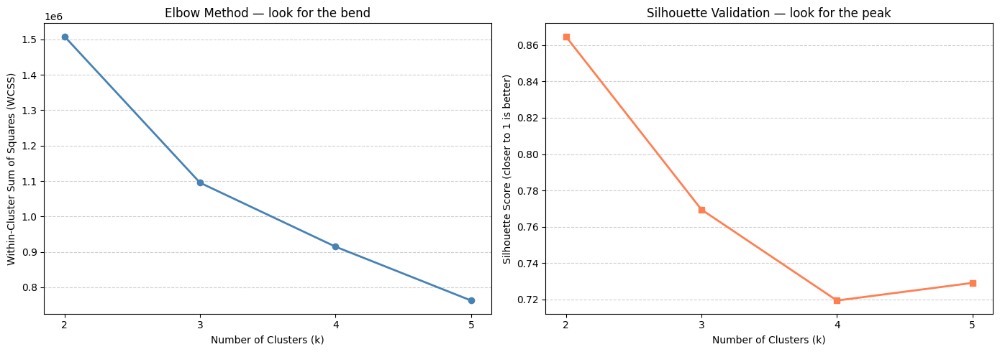


Highest silhouette score at k=2 (0.8648)


In [0]:
# --- K-Means Clustering: Optimal k Selection ---

k_range = range(2, 6)
wcss_values = []
silhouette_scores_list = []

print("Evaluating K-Means models (k=2 to 5)...")
print("-" * 55)

for k in k_range:
    km = SklearnKMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_train_sc)
    
    wcss = km.inertia_
    wcss_values.append(wcss)
 
    sample_size = 5000 
    if len(X_train_sc) > sample_size:
        idx = np.random.choice(len(X_train_sc), sample_size, replace=False)
        sil = silhouette_score(X_train_sc[idx], labels[idx], metric="euclidean")
    else:
        sil = silhouette_score(X_train_sc, labels, metric="euclidean")
        
    silhouette_scores_list.append(round(sil, 4))
    print(f"   k={k}  |  WCSS = {wcss:,.2f}  |  Silhouette = {sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), wcss_values, marker="o", color="steelblue", linewidth=2)
axes[0].set_xlabel("Number of Clusters (k)")
axes[0].set_ylabel("Within-Cluster Sum of Squares (WCSS)")
axes[0].set_title("Elbow Method — look for the bend")
axes[0].set_xticks(list(k_range))
axes[0].grid(axis="y", linestyle="--", alpha=0.6)

axes[1].plot(list(k_range), silhouette_scores_list, marker="s", color="coral", linewidth=2)
axes[1].set_xlabel("Number of Clusters (k)")
axes[1].set_ylabel("Silhouette Score (closer to 1 is better)")
axes[1].set_title("Silhouette Validation — look for the peak")
axes[1].set_xticks(list(k_range))
axes[1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

best_k_idx = silhouette_scores_list.index(max(silhouette_scores_list))
best_k = list(k_range)[best_k_idx]
print(f"\nHighest silhouette score at k={best_k} ({max(silhouette_scores_list):.4f})")

In [0]:
# --- K-Means: Train final model ---
OPTIMAL_K = best_k  # from Cell 86

km_final = SklearnKMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(X_train_sc)

pdf_train = pd.DataFrame(X_train_sc, columns=ML_FEATURES)
pdf_train["cluster"] = cluster_labels
pdf_train["dropout_risk"] = y_train

print(f"K-Means model trained with k={OPTIMAL_K}")
print("\nCluster distribution:")
print(pdf_train["cluster"].value_counts().sort_index())

K-Means model trained with k=2

Cluster distribution:
cluster
0      5242
1    233090
Name: count, dtype: int64


In [0]:
# --- Cluster Profiling ---
cluster_profile = pdf_train.groupby("cluster").agg(
    student_count        = ("cluster",                "count"),
    avg_interactions     = ("total_interactions",     "mean"),
    avg_active_days      = ("active_days",            "mean"),
    avg_sessions         = ("learning_sessions",      "mean"),
    avg_responses        = ("question_responses",     "mean"),
    avg_submissions      = ("submissions",            "mean"),
    avg_daily_intensity  = ("avg_interactions_per_day","mean"),
    avg_unique_sources   = ("unique_sources",         "mean"),
).round(2)

print("Cluster Profiles")
print(cluster_profile.to_string())
print()
print("Interpretation guide:")
print("  High avg_interactions + high avg_active_days → Power users / highly engaged")
print("  Low  avg_interactions + low  avg_active_days → At-risk / disengaged")

Cluster Profiles
         student_count  avg_interactions  avg_active_days  avg_sessions  avg_responses  avg_submissions  avg_daily_intensity  avg_unique_sources
cluster                                                                                                                                         
0                 5242              4.77             4.75          4.76           4.41             4.72                 2.55                2.87
1               233090             -0.11            -0.11         -0.11          -0.10            -0.11                -0.06               -0.06

Interpretation guide:
  High avg_interactions + high avg_active_days → Power users / highly engaged
  Low  avg_interactions + low  avg_active_days → At-risk / disengaged


In [0]:
# --- Cluster vs Dropout Risk ---
dropout_by_cluster = pdf_train.groupby("cluster").agg(
    student_count    = ("dropout_risk", "count"),
    dropout_count    = ("dropout_risk", "sum"),
    dropout_rate_pct = ("dropout_risk", "mean")
)
dropout_by_cluster["dropout_rate_pct"] = (
    dropout_by_cluster["dropout_rate_pct"] * 100
).round(2)

print("Dropout Rate by Cluster")
print(dropout_by_cluster.to_string())

Dropout Rate by Cluster
         student_count  dropout_count  dropout_rate_pct
cluster                                                
0                 5242            341              6.51
1               233090          71228             30.56


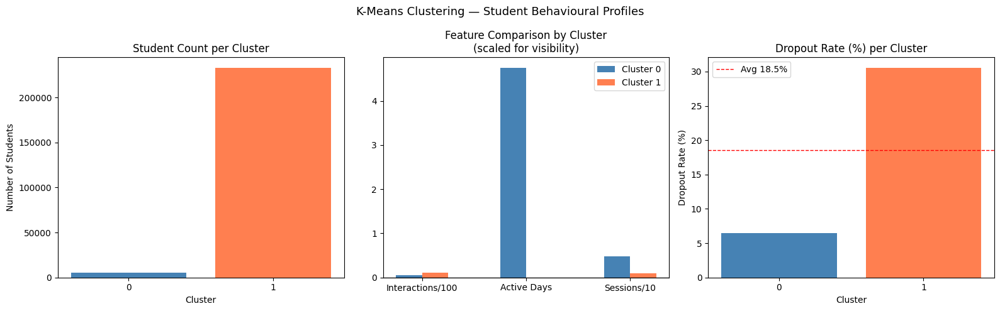

In [0]:
# --- K-Means Visualisation ---

all_colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple", "orange"]
bar_colors = all_colors[:OPTIMAL_K]  

profile_pd  = cluster_profile.reset_index()
dropout_pd  = dropout_by_cluster.reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].bar(profile_pd["cluster"].astype(str),
            profile_pd["student_count"], color=bar_colors)
axes[0].set_title("Student Count per Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Number of Students")

features_to_plot = ["avg_interactions", "avg_active_days", "avg_sessions"]
x = np.arange(len(features_to_plot))
width = 0.25

for i, row in profile_pd.iterrows():
    values = [row["avg_interactions"]/100, row["avg_active_days"], row["avg_sessions"]/10]
    min_val = min(values)
    if min_val <= 0:
        values = [v - min_val + 1e-3 for v in values]
    axes[1].bar(x + i * width, values, width,
                label=f"Cluster {int(row['cluster'])}", color=bar_colors[i])

axes[1].set_title("Feature Comparison by Cluster\n(scaled for visibility)")
axes[1].set_xticks(x + width * (OPTIMAL_K - 1) / 2)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xticklabels(["Interactions/100", "Active Days", "Sessions/10"])
axes[1].legend()

axes[2].bar(dropout_pd["cluster"].astype(str),
            dropout_pd["dropout_rate_pct"], color=bar_colors)
axes[2].set_title("Dropout Rate (%) per Cluster")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel("Dropout Rate (%)")
axes[2].axhline(y=dropout_pd["dropout_rate_pct"].mean(),
                color="red", linestyle="--", linewidth=1,
                label=f"Avg {dropout_pd['dropout_rate_pct'].mean():.1f}%")
axes[2].legend()

plt.suptitle("K-Means Clustering — Student Behavioural Profiles", fontsize=13)
plt.tight_layout()
plt.show()

── Model Comparison — All 6 Classifiers ────────────────────────
                         F1  Accuracy  AUC-ROC
Random Forest        0.6329    0.6935   0.6378
Logistic Regression  0.5762    0.6995   0.6039
SVM                  0.5761    0.6995   0.6035
GBT                  0.5766    0.6996   0.6392
MLP (Neural Net)     0.5761    0.6997   0.6209
Decision Tree        0.6283    0.6915   0.6215

Best model by F1      : Random Forest (0.6329)
Best model by AUC-ROC : GBT (0.6392)


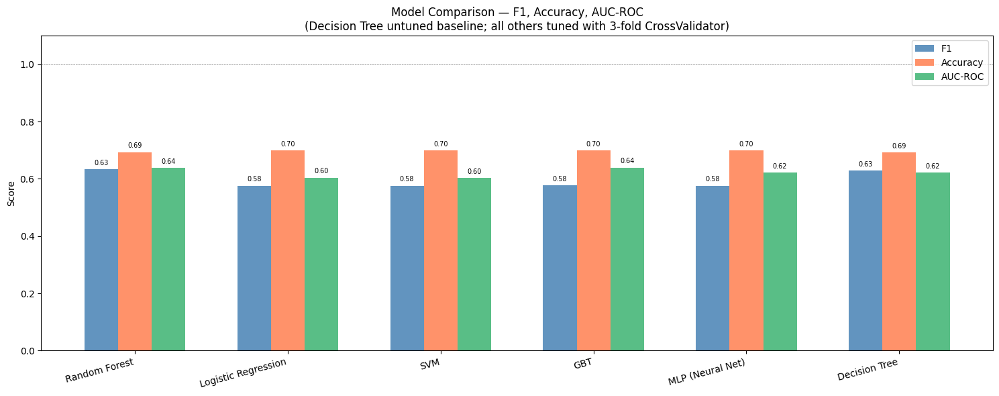

In [0]:
#Model Comparison - All 6 Classifiers
print("── Model Comparison — All 6 Classifiers ────────────────────────")
print(comparison_df.to_string())
print()
print(f"Best model by F1      : {comparison_df['F1'].idxmax()} ({comparison_df['F1'].max():.4f})")
print(f"Best model by AUC-ROC : {comparison_df['AUC-ROC'].idxmax()} ({comparison_df['AUC-ROC'].max():.4f})")

metrics_to_plot = ["F1", "Accuracy", "AUC-ROC"]
x      = np.arange(len(comparison_df))
width  = 0.22          
colors = ["steelblue", "coral", "mediumseagreen"]

fig, ax = plt.subplots(figsize=(15, 6))    
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, comparison_df[metric], width,
           label=metric, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(comparison_df.index, rotation=15, ha="right")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.5)
ax.legend()
ax.set_title("Model Comparison — F1, Accuracy, AUC-ROC\n(Decision Tree untuned baseline; all others tuned with 3-fold CrossValidator)")

for i, metric in enumerate(metrics_to_plot):
    for j, val in enumerate(comparison_df[metric]):
        ax.text(j + i * width, val + 0.01, f"{val:.2f}",
                ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.show()

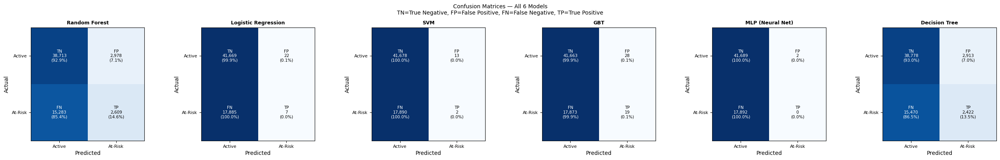

Key insight:
  FN (bottom-left) = at-risk students predicted as active — most costly error
  FP (top-right)   = active students flagged as at-risk — less critical
  The best model minimises FN while keeping FP reasonable.

  Decision Tree is included as an untuned baseline to show the
  improvement achieved by ensemble methods (RF, GBT) over a
  single tree, and to demonstrate interpretability trade-offs.


In [0]:
#Confusion Matrix Heatmaps — All 6 Models

models = {
    "Random Forest":       best_rf_model,
    "Logistic Regression": best_lr_model,
    "SVM":                 best_svm_model,
    "GBT":                 best_gbt_model,
    "MLP":                 best_mlp_model,
    "Decision Tree":       dt_model,        
}

fig, axes = plt.subplots(1, 6, figsize=(26, 4))   

for ax, (name, model) in zip(axes, tuned_trained.items()):
    from sklearn.metrics import confusion_matrix
    y_pred = model.predict(X_test_sc)
    cm = confusion_matrix(y_test, y_pred)

    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm_pct, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)
    ax.set_title(name, fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Active", "At-Risk"], fontsize=8)
    ax.set_yticklabels(["Active", "At-Risk"], fontsize=8)

    labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(j, i,
                    f"{labels[i][j]}\n{cm[i][j]:,}\n({cm_pct[i][j]:.1f}%)",
                    ha="center", va="center",
                    color="white" if cm_pct[i][j] > 60 else "black",
                    fontsize=7.5)

plt.suptitle(
    "Confusion Matrices — All 6 Models\n"
    "TN=True Negative, FP=False Positive, FN=False Negative, TP=True Positive",
    fontsize=10
)
plt.tight_layout()
plt.show()

print("Key insight:")
print("  FN (bottom-left) = at-risk students predicted as active — most costly error")
print("  FP (top-right)   = active students flagged as at-risk — less critical")
print("  The best model minimises FN while keeping FP reasonable.")
print()
print("  Decision Tree is included as an untuned baseline to show the")
print("  improvement achieved by ensemble methods (RF, GBT) over a")
print("  single tree, and to demonstrate interpretability trade-offs.")

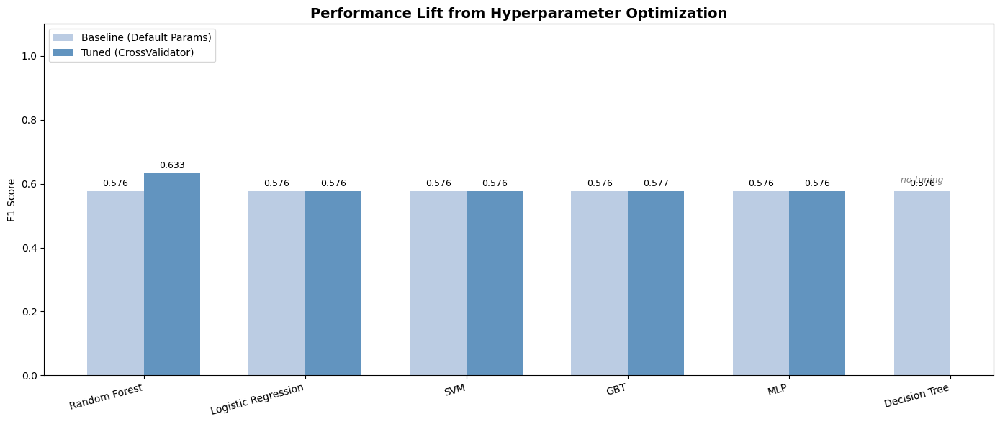

Key Insight: The Decision Tree provides a baseline for interpretability.
The delta between light and dark blue bars represents the ROI of the tuning process.


In [0]:
# --- Baseline vs Tuned: Improvement Comparison ---

# 1. DATA PREPARATION
names = ["Random Forest", "Logistic Regression", "SVM", "GBT", "MLP", "Decision Tree"]

baseline_vals = [
    rf_baseline_f1, lr_baseline_f1, svm_baseline_f1, 
    gbt_baseline_f1, mlp_baseline_f1, dt_baseline_f1
]
ed
tuned_vals = [
    rf_tuned_f1, lr_tuned_f1, svm_tuned_f1, 
    gbt_tuned_f1, mlp_tuned_f1, 0  
]

# 2. PLOTTING
x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - width/2, baseline_vals, width, 
               label="Baseline (Default Params)", color="lightsteelblue", alpha=0.85)

tuned_x = [i + width/2 for i, v in enumerate(tuned_vals) if v > 0]
tuned_y = [v for v in tuned_vals if v > 0]
bars2 = ax.bar(tuned_x, tuned_y, width, 
               label="Tuned (CrossValidator)", color="steelblue", alpha=0.85)

# 3. FORMATTING & ANNOTATIONS
ax.text(5 - width/2, baseline_vals[5] + 0.02, "no tuning", 
        ha="center", va="bottom", fontsize=9, color="gray", style="italic")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("F1 Score")
ax.set_ylim(0, 1.1)
ax.legend(loc="upper left")
ax.set_title("Performance Lift from Hyperparameter Optimization", fontsize=14, fontweight="bold")

def add_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

add_labels(bars1)
add_labels(bars2)

plt.tight_layout()
plt.show()

print("Key Insight: The Decision Tree provides a baseline for interpretability.")
print("The delta between light and dark blue bars represents the ROI of the tuning process.")

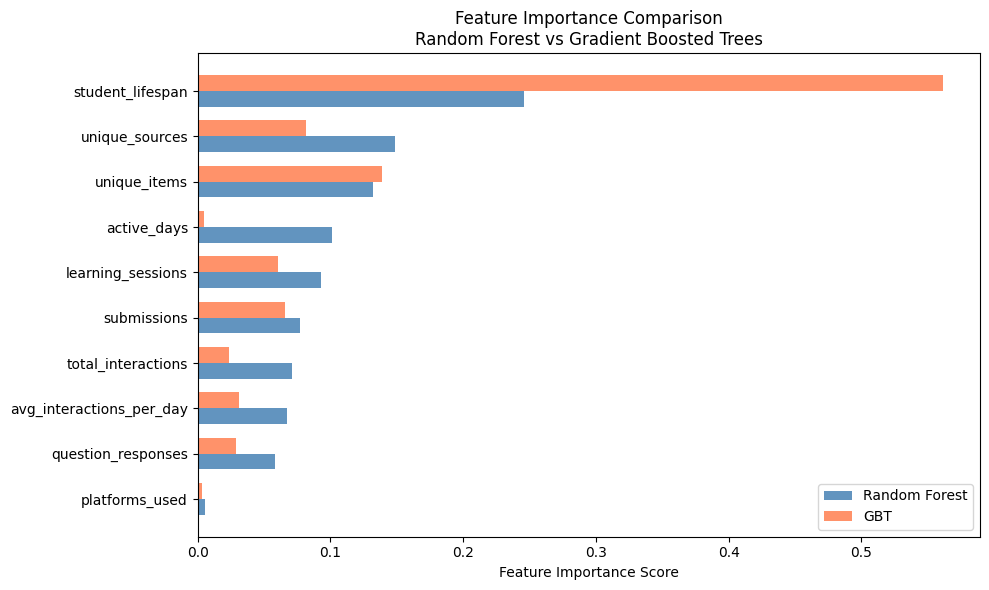


Interpretation:
  Features where both models agree (similar bar lengths) are robustly
  important — they contribute regardless of model type.
  Discrepancies may indicate features that are only useful non-linearly.


In [0]:
#Feature Importance: Random Forest vs GBT
rf_importances  = best_rf_model.feature_importances_
gbt_importances = best_gbt_model.feature_importances_

imp_df = pd.DataFrame({
    "Feature":        feature_names,
    "Random Forest":  rf_importances,
    "GBT":            gbt_importances
}).sort_values("Random Forest", ascending=True)

x     = np.arange(len(imp_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(x - width/2, imp_df["Random Forest"], width,
        label="Random Forest", color="steelblue", alpha=0.85)
ax.barh(x + width/2, imp_df["GBT"],           width,
        label="GBT",           color="coral",     alpha=0.85)

ax.set_yticks(x)
ax.set_yticklabels(imp_df["Feature"])
ax.set_xlabel("Feature Importance Score")
ax.set_title("Feature Importance Comparison\nRandom Forest vs Gradient Boosted Trees")
ax.legend()
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  Features where both models agree (similar bar lengths) are robustly")
print("  important — they contribute regardless of model type.")
print("  Discrepancies may indicate features that are only useful non-linearly.")